In [1]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Toy simulator

Simulates a point source population on top of an isotropic background.

In [44]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = 64  # Number of pixels
counts_min = 100  # Minimum and maximum counts emitted by each PS
counts_max = 100
fwhm_psf = 0.1  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=True):
    
    # iso
    mu_iso = np.random.uniform(0, 50)
    
    # iso PS
    mu_ps_iso = np.random.uniform(0, 100)
    n_ps_iso = np.random.poisson(mu_ps_iso)
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    # csp PS
    mu_ps_csp = np.random.uniform(0, 100)
    n_ps_csp = np.random.poisson(mu_ps_csp)
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    # disk PS
    mu_ps_disk = np.random.uniform(0, 100)
    n_ps_disk = np.random.poisson(mu_ps_disk)
    z_x_disk = np.array([norm.rvs(loc=0, scale=0.4, size=(n_ps_disk,)),
                         norm.rvs(loc=0, scale=0.6, size=(n_ps_disk,))])
    z_c_disk = np.random.uniform(counts_min, counts_max, n_ps_disk)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))
    
    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    if n_ps_disk > 0:
        mu_signal_disk = binned_statistic_2d(x=z_x_disk[0], y=z_x_disk[1], values=z_c_disk, statistic='sum', bins=bins).statistic
    else:
        mu_signal_disk =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map \
                     + convolve(mu_signal_iso, kernel) \
                     + convolve(mu_signal_csp, kernel) \
                     + convolve(mu_signal_disk, kernel) )

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        pass
#         mx, my = np.meshgrid(np.linspace(-1,1,100), np.linspace(-1,1,100))
#         def plot_gaussian(sx, sy, xc=0, yc=0):
#             return np.exp(-(mx-xc)**2/(2*sx**2)-(my-yc)**2/(2*sy**2))
        
#         fig, axs = plt.subplots(1, 2, figsize=(10,5))
#         axs[0].imshow(counts_binned, extent=(t_min, t_max, t_min, t_max))
        
#         z_disk = plot_gaussian(0.6, 0.4, xc=0, yc=0)
#         axs[1].imshow(z_disk)
#         plt.show()
    
    return mu_ps_iso, mu_ps_csp, mu_ps_disk, mu_iso, counts_binned

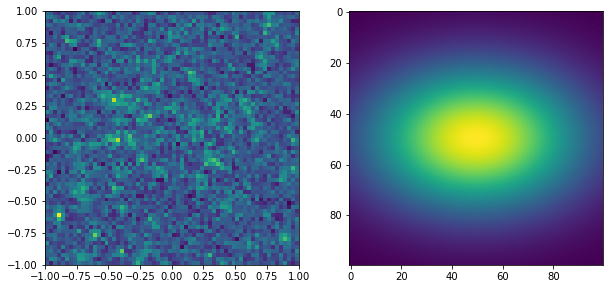

In [41]:
_, _, _, _, x = simulate(plot=True)

In [43]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=100):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

Simulate training sample

In [45]:
from tqdm import tqdm
simulations = [simulate() for _ in tqdm(range(20000))]

100%|████████████████████████████████████████████████████████████████████████| 20000/20000 [00:58<00:00, 340.24it/s]


In [46]:
x = list(map(itemgetter(-1), simulations))
mu_ps_iso  = list(map(itemgetter(0), simulations))
mu_ps_csp  = list(map(itemgetter(1), simulations))
mu_ps_disk = list(map(itemgetter(2), simulations))
mu_iso = list(map(itemgetter(3), simulations))
x_pspec = np.array([power_spectrum(x_i) for x_i in x])
x_hist = np.array([counts_histogram(x_i) for x_i in x])

Plot mean power spectrum over simulations

Text(0.5, 1.0, 'Mean power spectrum')

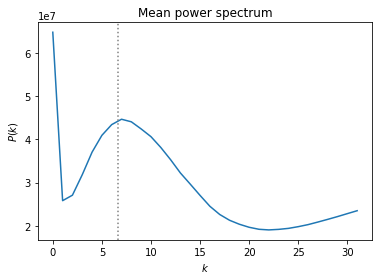

In [10]:
plt.plot(np.mean(x_pspec, axis=0))
plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)  # Scale of the PSF

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")

Text(0.5, 1.0, 'Mean histogram')

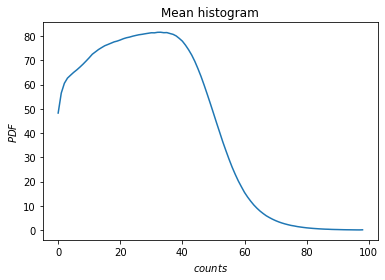

In [11]:
plt.plot(np.mean(x_hist, axis=0))

plt.xlabel("$counts$")
plt.ylabel("$PDF$")
plt.title("Mean histogram")

## Mutual information

$$\mathrm{MI}(X ; Y)=D_{\mathrm{KL}}\left(P_{(X, Y)} \| P_{X} \otimes P_{Y}\right)$$

$$\mathrm{MI}(X ; Y)=\int_{\mathcal{Y}} \int_{\mathcal{X}} p_{(X, Y)}(x, y) \log \left(\frac{p_{(X, Y)}(x, y)}{p_{X}(x) p_{Y}(y)}\right) d x d y$$

In [12]:
def calc_MI(X, Y, bins):
    """ Compute mutual information with density estimation by binning
    """
    c_XY = np.histogram2d(X, Y, bins)[0]
    c_X = np.histogram(X, bins)[0]
    c_Y = np.histogram(Y, bins)[0]

    H_X = shannon_entropy(c_X)
    H_Y = shannon_entropy(c_Y)
    H_XY = shannon_entropy(c_XY)

    MI = H_X + H_Y - H_XY
    return MI

def shannon_entropy(c):
    """ Shannon entropy
    """
    c_normalized = c / float(np.sum(c))
    c_normalized = c_normalized[np.nonzero(c_normalized)]
    H = -sum(c_normalized* np.log2(c_normalized))  
    return H

Compute the "true" MI between parameters of interest and the power spectrum.

Text(0.5, 1.0, 'Ground truth mutual information')

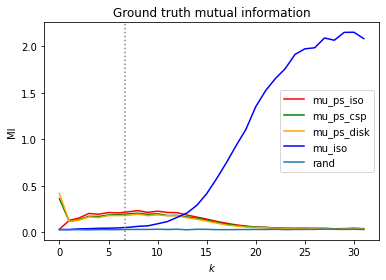

In [47]:
n_bins = 32

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(mu_ps_iso, x_pspec[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_iso", color='red')

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(mu_ps_csp, x_pspec[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_csp", color='green')

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(mu_ps_disk, x_pspec[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_disk", color='orange')

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(x_pspec[:, i], mu_iso, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

# Uncorrelate MI, as a test baseline

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(x_pspec[:, i], np.random.uniform(0, 3, size=x_pspec[:, i].shape), n_bins))
    
plt.plot(MI, label="rand")

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

plt.title("Ground truth mutual information")

## What scales is a ResNet using?

Use a CNN, specifically a ResNet, to predict the parameters of interest and compute their MI with the power spectrum to understand which scales the network is leveraging.

In [14]:
import sys
sys.path.append("../")
from models.resnet import ResNetEstimator

In [15]:
import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import MLFlowLogger

from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

### Define and train CNN model

Define our model---a simple regression task.

In [16]:
from resnetregressor import ResNetRegressor

In [13]:
class ResNetRegressor(pl.LightningModule):
    def __init__(self, n_out=3):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.resnet = ResNetEstimator(cfg=18, n_out=n_out, log_input=False)
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.resnet(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [48]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

Global seed set to 99


99

Create training dataloader

In [49]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

y = torch.Tensor(np.array([mu_ps_iso, mu_ps_csp, mu_ps_disk, mu_iso])).T

# Normalize inputs
y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

x = torch.Tensor(x)

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=0, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=0, shuffle=False)

Instantiate and train model. Note GPU option turned on by default.

In [50]:
model = ResNetRegressor(n_out=4)

In [51]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=4, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);  # Load best epoch by validation loss

/n/home07/yitians/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:849: UserWarning: You requested multiple GPUs but did not specify a backend, e.g. `Trainer(strategy="dp"|"ddp"|"ddp2")`. Setting `strategy="ddp_spawn"` for you.
  rank_zero_warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Global seed set to 99
Global seed set to 99
Global seed set to 99
Global seed set to 99
initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 4 processes
------------------------------------------

Epoch 0:  90%|████████▉ | 71/79 [00:01<00:00, 38.46it/s, loss=0.426, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 1:  90%|████████▉ | 71/79 [00:01<00:00, 39.87it/s, loss=0.374, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 2:  90%|████████▉ | 71/79 [00:01<00:00, 39.72it/s, loss=0.341, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 3:  90%|████████▉ | 71/79 [00:01<00:00, 39.99it/s, loss=0.278, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 4:  90%|████████▉ | 71/79 [00:01<00:00, 39.75it/s, loss=0.2, v_num=6.33e+7]  
Validating: 0it [00:00, ?it/s]
Epoch 5:  90%|████████▉ | 71/79 [00:01<00:00, 40.11it/s, loss=0.15, v_num=6.33e+7] 
Validating: 0it [00:00, ?it/s]
Epoch 6:  90%|████████▉ | 71/79 [00:01<00:00, 39.95it/s, loss=0.129, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 7:  90%|████████▉ | 71/79 [00:01<00:00, 40.26it/s, loss=0.0966, v_num=6.33e+7]
Validating: 0it [00:00, ?it/s]
Epoch 8:  90%|████████▉ | 71/79 [00:01<00:00, 40.32it/s, loss=0.0862, v_num=6.3

/n/home07/yitians/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/plugins/training_type/ddp_spawn.py:307: UserWarning: cleaning up ddp environment...
  rank_zero_warn("cleaning up ddp environment...")


### Test trained model

In [52]:
simulations_test = [simulate() for _ in tqdm(range(20000))]

x_test = list(map(itemgetter(-1), simulations_test))
mu_ps_iso_test = list(map(itemgetter(0), simulations_test))
mu_ps_csp_test = list(map(itemgetter(1), simulations_test))
mu_ps_disk_test = list(map(itemgetter(2), simulations_test))
mu_iso_test = list(map(itemgetter(3), simulations_test))
x_pspec_test = np.array([power_spectrum(x_i) for x_i in x_test])
x_hist_test = np.array([counts_histogram(x_i) for x_i in x_test])

100%|████████████████████████████████████████████████████████████████████████| 20000/20000 [00:58<00:00, 344.27it/s]


In [53]:
# Normalize
y_test =  torch.Tensor(np.array([mu_ps_iso_test, mu_ps_csp_test, mu_ps_disk_test, mu_iso_test])).T
y_test = (y_test - y_mean) / y_std

x_test = torch.Tensor(x_test)

In [54]:
dataset_test = TensorDataset(x_test, y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [55]:
mu_ps_iso_test, mu_ps_csp_test, mu_ps_disk_test, mu_iso_test = y_test.detach().numpy().T

In [56]:
model.to('cuda')

mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b.to('cuda')).cpu())
    del x_b

100%|███████████████████████████████████████████████████████████████████████████████| 79/79 [00:01<00:00, 68.19it/s]


In [57]:
mu_ps_iso_pred, mu_ps_csp_pred, mu_ps_disk_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

tmpsave

In [58]:
import pickle

In [59]:
pickle.dump(model, open('3cpn_0.6.modelp', 'wb'))

### Integrated gradients

$$\text {IntegratedGrads}_{i}(x)::=\left(x_{i}-x_{i}^{\prime}\right) \times \int_{\alpha=0}^{1} \frac{\partial F\left(x^{\prime}+\alpha \times\left(x-x^{\prime}\right)\right)}{\partial x_{i}} d \alpha$$

In [29]:
from captum.attr import IntegratedGradients

In [60]:
ig = IntegratedGradients(model)

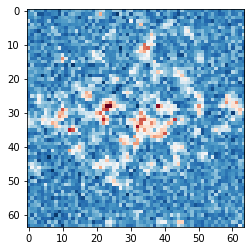

In [33]:
i_samp = 10086
plt.imshow(x_test[i_samp].detach().numpy(), cmap='RdBu_r')

tensor([0.0575], device='cuda:0', dtype=torch.float64)
tensor([0.1057], device='cuda:0', dtype=torch.float64)
tensor([0.0472], device='cuda:0', dtype=torch.float64)
tensor([-0.0598], device='cuda:0', dtype=torch.float64)


Text(0.5, 1.0, 'Original map')

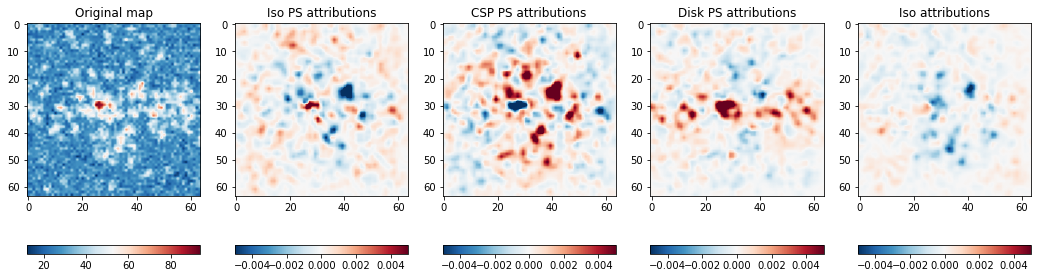

In [42]:
fig, ax = plt.subplots(figsize=(18,6), ncols=5)

titles = ["Iso PS attributions", "CSP PS attributions", "Disk PS attributions", "Iso attributions"]

for i in range(4):
    
    baseline = (torch.mean(x_test[i_samp]) * torch.ones((1,64,64))).to('cuda')
#     baseline = torch.rand((1,64,64)).to('cuda')
    
    attributions, approximation_error = ig.attribute(x_test[i_samp].unsqueeze(0).to('cuda'),
                                        target=i,
                                        baselines=baseline,
                                        n_steps=1000,
                                        return_convergence_delta=True)
    
    attr = ax[i + 1].imshow(convolve(attributions[0].cpu().detach().numpy(), kernel), cmap='RdBu_r', vmin=-0.005, vmax=0.005,)
    fig.colorbar(attr, ax=ax[i + 1], orientation='horizontal')
    ax[i + 1].set_title(titles[i])

    print(approximation_error)
    
map = ax[0].imshow(x_test[i_samp].detach().numpy(), cmap='RdBu_r')
fig.colorbar(map, ax=ax[0], orientation='horizontal')
ax[0].set_title("Original map")

In [61]:
attr_map = np.zeros((200, 4, x_test[0].shape[0], x_test[0].shape[1]))

for i_samp in tqdm(range(200)):
    
    baseline = (torch.mean(x_test[i_samp]) * torch.ones((1,64,64))).to('cuda')
    
    for i in range(4):

        attributions, approximation_error = ig.attribute(x_test[i_samp].unsqueeze(0).to('cuda'),
                                            target=i,
                                            baselines=baseline,
                                            n_steps=1000,
                                            return_convergence_delta=True)
        
        attr_map[i_samp, i] += attributions[0].cpu().detach().numpy()


100%|█████████████████████████████████████████████████████████████████████████████| 200/200 [03:25<00:00,  1.03s/it]


In [ ]:
fig, ax = plt.subplots(figsize=(18,6), ncols=4)

titles = ["Iso PS attributions", "CSP PS attributions", "Disk PS attributions", "Iso attributions"]

for i in range(4):
    
    attr = ax[i].imshow(convolve(np.mean(attr_map, axis=0)[i], kernel), cmap='RdBu_r')
    fig.colorbar(attr, ax=ax[i], orientation='horizontal')
    ax[i].set_title(titles[i])

### Predicted vs true

In [33]:
tags = ["Iso PS", "CSP PS", "Disk PS", "Iso"]
mu_tests = [mu_ps_iso_test, mu_ps_csp_test, mu_ps_disk_test, mu_iso_test]
mu_preds = [mu_ps_iso_pred, mu_ps_csp_pred, mu_ps_disk_pred, mu_iso_pred]
residual = [ mu_preds[i]-mu_tests[i] for i in range(4) ]

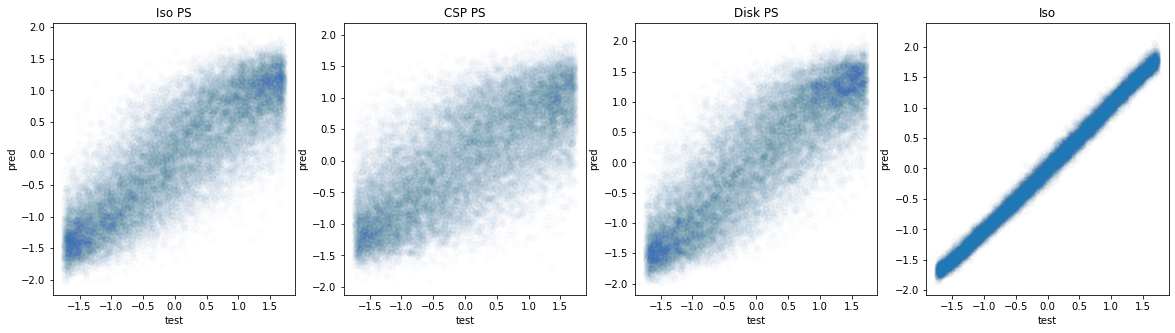

In [34]:
fig, axs = plt.subplots(1, 4, figsize=(20,5))

for i in range(4):
    axs[i].scatter(mu_tests[i], mu_preds[i], alpha=0.01)
    axs[i].set(xlabel='test', ylabel='pred', title=tags[i])

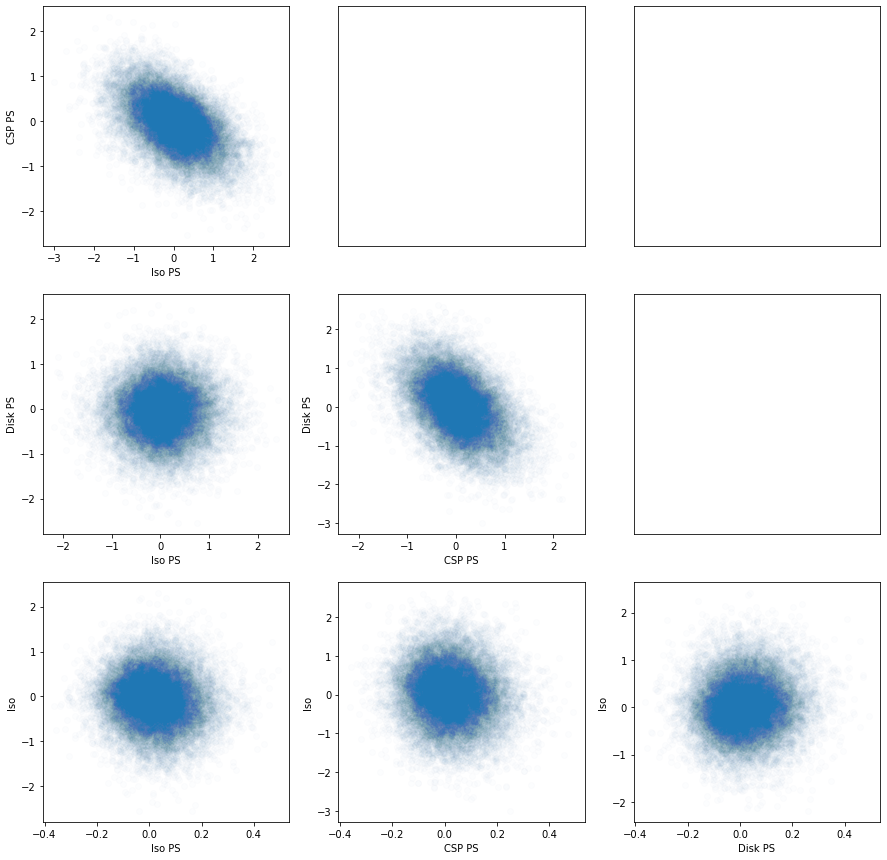

In [35]:
fig, axs = plt.subplots(3, 3, figsize=(15,15))
for p_i in range(3):
    for p_j in range(3):
        if p_j <= p_i:
            i = p_i + 1
            j = p_j
            axs[p_i, p_j].scatter(residual[i], residual[j], alpha=0.01)
            axs[p_i, p_j].set(ylabel=tags[i], xlabel=tags[j])
        else:
            axs[p_i, p_j].axes.xaxis.set_visible(False)
            axs[p_i, p_j].axes.yaxis.set_visible(False)
plt.savefig('tmp.pdf', bbox_inches='tight')

### Compute MI of prediction

Text(0, 0.5, 'MI')

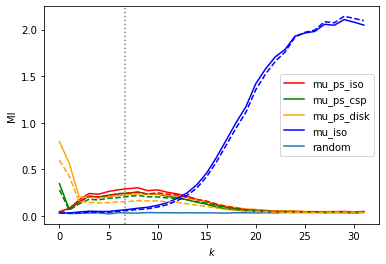

In [36]:
n_bins = 32

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_iso_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_iso", color='red')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_csp_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_csp", color='green')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_disk_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps_disk", color='orange')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], np.random.uniform(0, 3, size=x_pspec_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_iso_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_csp_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='green', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_disk_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='orange', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

The CNN seems to be accurately leveraging various scales to predict the two parameters.

## What scales is a PCA decomposition using?

Perform a PCA decomposition and train it with a simple MLP.

In [180]:
from sklearn.decomposition import PCA, IncrementalPCA

Compute PCA of training data

In [186]:
pca = PCA(n_components=64)

x_flattened = x.reshape(-1, n_t * n_t)
x_pca = pca.fit_transform(x_flattened)

x_pca_mean = x_pca.mean(axis=0)
x_pca_std = x_pca.std(axis=0)

x_pca = (x_pca - x_pca_mean) / x_pca_std

Text(0, 0.5, '% variance explained')

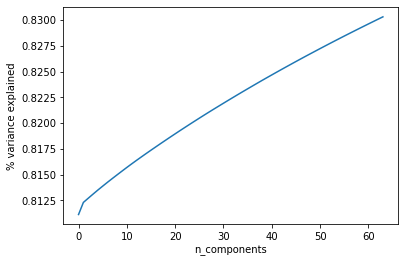

In [187]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("n_components")
plt.ylabel("% variance explained")

### Define and train model

In [188]:
## A simple MLP

def build_mlp(input_dim, hidden_dim, output_dim, layers, activation='relu'):
    """Create a MLP from the configurations
    """
    
    activation = nn.ReLU

    seq = [nn.Linear(input_dim, hidden_dim), activation()]
    for _ in range(layers):
        seq += [nn.Linear(hidden_dim, hidden_dim), activation()]
    seq += [nn.Linear(hidden_dim, output_dim)]

    return nn.Sequential(*seq)

In [192]:
class PCANet(pl.LightningModule):
    def __init__(self, n_out=3):
        super().__init__()
        
        self.save_hyperparameters()
        
        # Simple 4-layer MLP
        self.mlp = build_mlp(64, 128, n_out, 4, 'relu')
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.mlp(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

Define dataset, this time with PCA decomposition as input variable

In [193]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

Global seed set to 165


165

In [194]:
dataset = TensorDataset(torch.Tensor(x_pca), y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

Train model. Note not using GPU by default.

In [195]:
model = PCANet()

checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=0, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1303: UserWarning: GPU available but not used. Set the gpus flag in your trainer `Trainer(gpus=1)` or script `--gpus=1`.
  rank_zero_warn(
Set SLURM handle signals.

  | Name | Type       | Params
------------------------------------
0 | mlp  | Sequential | 74.8 K
1 | loss | MSELoss    | 0     
------------------------------------
74.8 K    Trainable params
0         Non-trainable params
74.8 K    Total params
0.299     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 165


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [196]:
x_test_flattened = x_test.reshape(-1, n_t * n_t)
x_test_pca = pca.fit_transform(x_test_flattened)
x_test_pca = (x_test_pca - x_pca_mean) / x_pca_std

In [197]:
dataset_test = TensorDataset(torch.Tensor(x_test_pca), y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [57]:
mu_ps_iso_test, mu_ps_csp_test, mu_iso_test = y_test.detach().numpy().T

In [58]:
mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b))
    del x_b

  0%|          | 0/79 [00:00<?, ?it/s]

In [59]:
mu_ps_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{ps, pred}$')

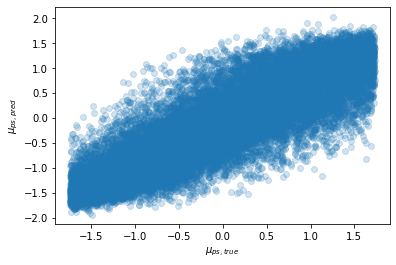

In [199]:
plt.scatter(mu_ps_iso_test, mu_ps_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

Text(0, 0.5, '$\\mu_{ps, pred}$')

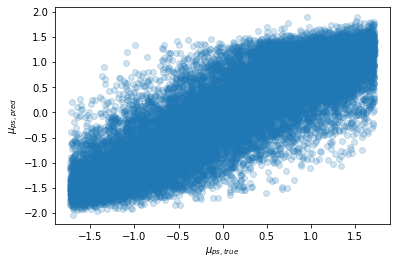

In [200]:
plt.scatter(mu_ps_csp_test, mu_ps_csp_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

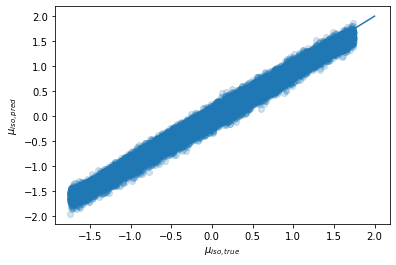

In [203]:
plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

plt.plot([0,2],[0,2])

Text(0, 0.5, 'MI')

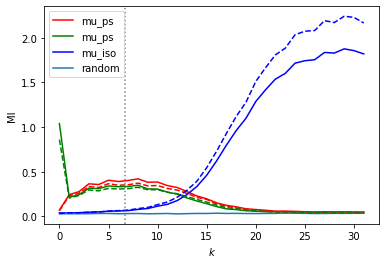

In [202]:
n_bins = 32

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_iso_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_csp_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='green')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], np.random.uniform(0, 3, size=x_pspec_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_iso_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_csp_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='green', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

Text(0, 0.5, 'MI')

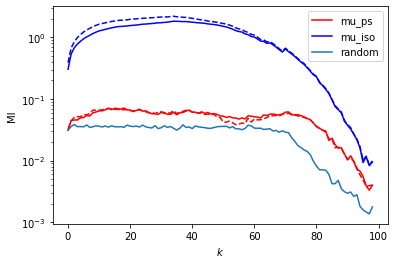

In [65]:
n_bins = 32

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_hist_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], np.random.uniform(0, 3, size=x_hist_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_hist_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

# plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.yscale("log")

plt.xlabel("$k$")
plt.ylabel("MI")